# **02 — K-MEANS CLUSTERING LOWONGAN KERJA**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler as SklearnScaler
from sklearn.cluster import KMeans as SklearnKMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
!pip install pyspark -q

from pyspark.sql import SparkSession
from pyspark.ml.clustering import KMeans as SparkKMeans
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import StandardScaler as SparkScaler
from pyspark.ml.evaluation import ClusteringEvaluator

spark = SparkSession.builder \
    .appName("JobMarketClustering") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()
spark.sparkContext.setLogLevel("ERROR")
print(f"Spark bisa digunakan")


Spark bisa digunakan


In [3]:
df = pd.read_csv("cleaned_dataset.csv")
print(f"Pandas df: {df.shape}")

Pandas df: (1465, 22)


In [4]:
spark_df = spark.read.csv("cleaned_dataset.csv", header=True, inferSchema=True)
print(f"Spark df : {spark_df.count()} baris, {len(spark_df.columns)} kolom")

Spark df : 3527 baris, 22 kolom


## 1. Encoding Fitur Kategorikal & Imputasi Gaji Kosong

In [5]:
le_jobtype   = LabelEncoder()
le_education = LabelEncoder()

df['job_type_enc']  = le_jobtype.fit_transform(df['job_type_clean'].fillna('Tidak Disebutkan'))
df['education_enc'] = le_education.fit_transform(df['education_clean'].fillna('Tidak Disebutkan'))
df['experience_years'] = df['experience_years'].fillna(0).astype(int)

features = ['experience_years', 'job_type_enc', 'education_enc']
X = df[features].copy()

print("=== Pengecekan Missing Value pada Fitur Klaster ===")
print(X.isnull().sum())
print(f"\nShape fitur: {X.shape}")

=== Pengecekan Missing Value pada Fitur Klaster ===
experience_years    0
job_type_enc        0
education_enc       0
dtype: int64

Shape fitur: (1465, 3)


## 2. Standarisasi Fitur

In [6]:
scaler = SklearnScaler()
X_scaled = scaler.fit_transform(X)
print(f"Fitur yang digunakan: {features}")
print(f"Shape matrix fitur  : {X_scaled.shape}")

Fitur yang digunakan: ['experience_years', 'job_type_enc', 'education_enc']
Shape matrix fitur  : (1465, 3)


## 3. Mencari Jumlah Klaster Optimal

=== ELBOW METHOD ===
  K=2 → WCSS=2998.4, Silhouette=0.4142
  K=3 → WCSS=1865.5, Silhouette=0.5375
  K=4 → WCSS=1199.7, Silhouette=0.5971
  K=5 → WCSS=966.9, Silhouette=0.6188
  K=6 → WCSS=789.2, Silhouette=0.6344
  K=7 → WCSS=641.3, Silhouette=0.6522
  K=8 → WCSS=544.3, Silhouette=0.6897
  K=9 → WCSS=458.5, Silhouette=0.6912
  K=10 → WCSS=395.1, Silhouette=0.7251


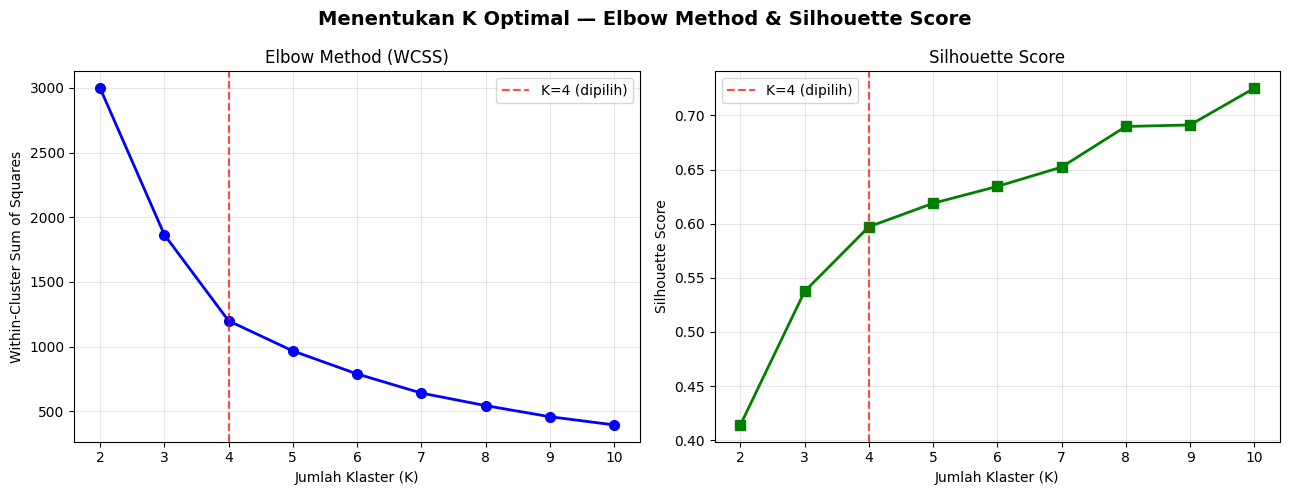


K=4 dipilih berdasarkan titik siku Elbow Method


In [7]:
print("=== ELBOW METHOD ===")
wcss_list = []
sil_list  = []
K_range   = range(2, 11)

for k in K_range:
    km = SklearnKMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss_list.append(km.inertia_)
    sil = silhouette_score(X_scaled, km.labels_)
    sil_list.append(sil)
    print(f"  K={k} → WCSS={km.inertia_:.1f}, Silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Menentukan K Optimal — Elbow Method & Silhouette Score",
             fontsize=14, fontweight='bold')

axes[0].plot(K_range, wcss_list, 'b-o', linewidth=2, markersize=7)
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='K=4 (dipilih)')
axes[0].set_title("Elbow Method (WCSS)")
axes[0].set_xlabel("Jumlah Klaster (K)")
axes[0].set_ylabel("Within-Cluster Sum of Squares")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, sil_list, 'g-s', linewidth=2, markersize=7)
axes[1].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='K=4 (dipilih)')
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Jumlah Klaster (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("\nK=4 dipilih berdasarkan titik siku Elbow Method")


## 4. K-Means dengan PySpark MLlib

In [8]:
df_encoded = spark.createDataFrame(
    df[['job_title','company_name','location',
        'experience_years','job_type_clean','education_clean',
        'job_type_enc','education_enc']]
)

assembler = VectorAssembler(
    inputCols=['experience_years','job_type_enc','education_enc'],
    outputCol='features_raw'
)
df_assembled = assembler.transform(df_encoded)

spark_scaler = SparkScaler(inputCol='features_raw', outputCol='features',
                           withStd=True, withMean=True)
scaler_model = spark_scaler.fit(df_assembled)
df_scaled_spark = scaler_model.transform(df_assembled)

K_OPTIMAL = 4
spark_kmeans = SparkKMeans(featuresCol='features', predictionCol='cluster',
                           k=K_OPTIMAL, seed=42, maxIter=20)
spark_model = spark_kmeans.fit(df_scaled_spark)
df_clustered_spark = spark_model.transform(df_scaled_spark)

evaluator = ClusteringEvaluator(featuresCol='features', predictionCol='cluster',
                                metricName='silhouette')
silhouette_spark = evaluator.evaluate(df_clustered_spark)

print(f"=== HASIL K-MEANS PYSPARK MLlib (K={K_OPTIMAL}) ===")
print(f"Silhouette Score: {silhouette_spark:.4f}")
print("\nDistribusi klaster:")
df_clustered_spark.groupBy('cluster').count().orderBy('cluster').show()

cluster_col = df_clustered_spark.select('cluster').toPandas()
df['cluster'] = cluster_col['cluster'].values
final_sil = silhouette_spark


=== HASIL K-MEANS PYSPARK MLlib (K=4) ===
Silhouette Score: 0.7162

Distribusi klaster:
+-------+-----+
|cluster|count|
+-------+-----+
|      0|  271|
|      1|  567|
|      2|  507|
|      3|  120|
+-------+-----+



## 5. Labeling Nama Klaster

=== PROFIL TIAP KLASTER ===
         jumlah_lowongan  avg_experience       top_jobtype  top_education
cluster                                                                  
0                    271            0.96  Tidak Disebutkan  S1 (Bachelor)
1                    567            0.86         Full-time  S1 (Bachelor)
2                    507            0.62         Full-time        SMA/SMK
3                    120            4.00         Full-time  S1 (Bachelor)



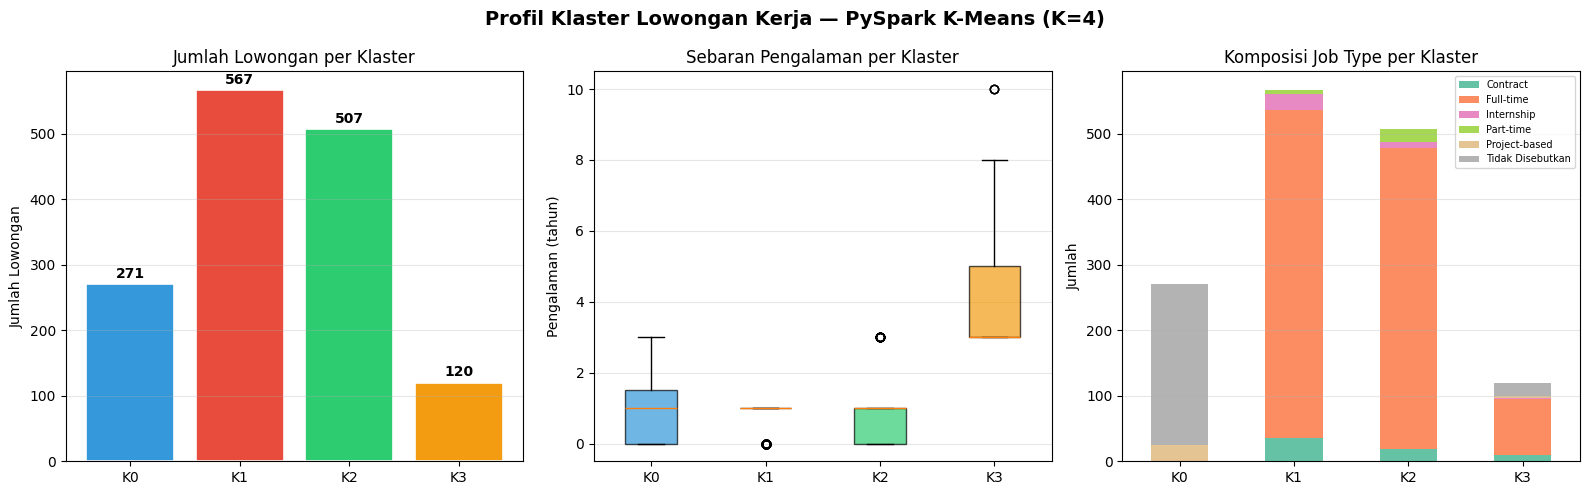

In [9]:
cluster_names = {}
for c in range(K_OPTIMAL):
    subset = df[df['cluster'] == c]
    avg_exp  = subset['experience_years'].mean()
    top_type = subset['job_type_clean'].mode()[0]
    top_edu  = subset['education_clean'].mode()[0]

    if avg_exp == 0 and 'SMA' in top_edu:
        cluster_names[c] = f"Klaster {c}: Fresh Graduate (SMA)"
    elif avg_exp <= 1.5 and 'Full-time' in top_type:
        cluster_names[c] = f"Klaster {c}: Junior Professional"
    elif avg_exp <= 3:
        cluster_names[c] = f"Klaster {c}: Mid-Level"
    else:
        cluster_names[c] = f"Klaster {c}: Senior Expert"

df['cluster_label'] = df['cluster'].map(cluster_names)

print("=== PROFIL TIAP KLASTER ===")
cluster_profile = df.groupby('cluster').agg(
    jumlah_lowongan=('job_title', 'count'),
    avg_experience=('experience_years', 'mean'),
    top_jobtype=('job_type_clean', lambda x: x.mode()[0]),
    top_education=('education_clean', lambda x: x.mode()[0]),
).round(2)
print(cluster_profile)
print()

COLORS = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Profil Klaster Lowongan Kerja — PySpark K-Means (K=4)",
             fontsize=14, fontweight='bold')

counts = df['cluster'].value_counts().sort_index()
bars = axes[0].bar([f"K{i}" for i in counts.index], counts.values,
                   color=COLORS, edgecolor='white', linewidth=1.2)
axes[0].set_title("Jumlah Lowongan per Klaster")
axes[0].set_ylabel("Jumlah Lowongan")
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

bp_data = [df[df['cluster'] == c]['experience_years'].values for c in range(K_OPTIMAL)]
bp = axes[1].boxplot(bp_data, labels=[f"K{c}" for c in range(K_OPTIMAL)], patch_artist=True)
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_title("Sebaran Pengalaman per Klaster")
axes[1].set_ylabel("Pengalaman (tahun)")
axes[1].grid(axis='y', alpha=0.3)

jt_dist = df.groupby(['cluster', 'job_type_clean']).size().unstack(fill_value=0)
jt_dist.index = [f"K{i}" for i in jt_dist.index]
jt_dist.plot(kind='bar', stacked=True, ax=axes[2], colormap='Set2')
axes[2].set_title("Komposisi Job Type per Klaster")
axes[2].set_ylabel("Jumlah")
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(loc='upper right', fontsize=7)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Reduksi Dimensi PCA & Scatter Plot 2D

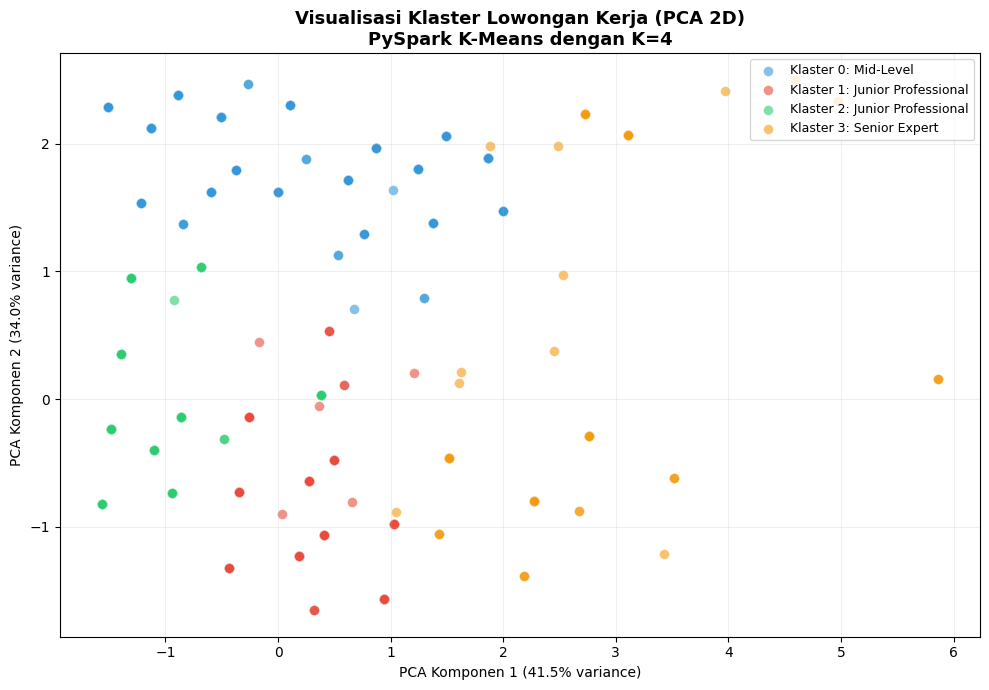

clustered_dataset.csv berhasil disimpan!

=== RINGKASAN FINAL ===
Engine      : Apache Spark MLlib
K optimal   : 4
Silhouette  : 0.7162
Total data  : 1465 baris

  Klaster 0: Mid-Level
  Klaster 1: Junior Professional
  Klaster 2: Junior Professional
  Klaster 3: Senior Expert


In [10]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

fig, ax = plt.subplots(figsize=(10, 7))
for c in range(K_OPTIMAL):
    mask = df['cluster'] == c
    ax.scatter(df.loc[mask, 'pca1'], df.loc[mask, 'pca2'],
               c=COLORS[c], label=cluster_names[c], alpha=0.6, s=50,
               edgecolors='white', linewidths=0.3)

ax.set_title("Visualisasi Klaster Lowongan Kerja (PCA 2D)\nPySpark K-Means dengan K=4",
             fontsize=13, fontweight='bold')
ax.set_xlabel(f"PCA Komponen 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PCA Komponen 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Simpan hasil
df.to_csv("clustered_dataset.csv", index=False)
print("clustered_dataset.csv berhasil disimpan!")
print(f"\n=== RINGKASAN FINAL ===")
print(f"Engine      : Apache Spark MLlib")
print(f"K optimal   : {K_OPTIMAL}")
print(f"Silhouette  : {final_sil:.4f}")
print(f"Total data  : {len(df)} baris")
print()
for k, v in cluster_names.items():
    print(f"  {v}")

spark.stop()